<a href="https://colab.research.google.com/github/Sakshi-HC-Gowda/Data-Science-and-Gen-AI/blob/main/Day_06_Gen_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
! nvidia-smi

Sat Jul 18 04:53:33 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   59C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
15360/1000

15.36

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
df = pd.read_csv('/content/breast-cancer.csv')
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [ ]:
df = df.drop(['id','Unnamed: 32'],axis=1)
df['diagnosis'] = df['diagnosis'].map({'M':0,'B':1}).astype(int)

In [ ]:
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,0,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,0,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,0,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,0,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [ ]:
X = df.iloc[:,1:]
y = df.iloc[:,0]

In [ ]:
y

,diagnosis
0,0
1,0
2,0
3,0
4,0
...,...
564,0
565,0
566,0
567,0


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
len(X_train),len(y_train)

(455, 455)

- TensorFlow - https://www.tensorflow.org/api_docs
- Keras - https://keras.io/api/

In [ ]:
# instead of giving the data to ML algorithms
# we will give the data ANN[Neural Networks]

import tensorflow
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Activation
from tensorflow.keras.activations import relu,sigmoid

In [ ]:
X_train.shape[1]

30

In [ ]:
# Define the architecture

model = Sequential()

# input layer to 1st hidden layer

model.add(Dense(units=128,kernel_initializer='he_uniform',activation=relu,input_dim = X_train.shape[1]))

# outcome from 1st hidden layer we will pass it to 2nd hidden layer

model.add(Dense(units=64,kernel_initializer='he_uniform',activation=relu))

# outcome from 2nd hidden layer we will pass it to 3rd hidden layer

model.add(Dense(units=32,kernel_initializer='he_uniform',activation=relu))

# outcome from 3rd hidden layer we will give it to 4th hidden layer

model.add(Dense(units=16,kernel_initializer='he_uniform',activation=relu))

# outcome from 4th hidden layer we will give it to the 5th hidden layer

model.add(Dense(units=8,kernel_initializer='he_uniform',activation=relu))

# outcome from 5th hidden layer to the Output layer

model.add(Dense(units=1,kernel_initializer= 'glorot_uniform',activation=sigmoid))

In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 128)            │         3,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,977 (58.50 KB)

 Trainable params: 14,977 (58.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# metrics

model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['acc'])

In [ ]:
X_train.shape

(455, 30)

In [ ]:
# Training the model

model.fit(X_train,y_train,batch_size = 20,validation_split=0.2,epochs=50)

Epoch 1/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 110ms/step - acc: 0.6786 - loss: 15.8065 - val_acc: 0.6703 - val_loss: 2.0388
Epoch 2/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - acc: 0.8159 - loss: 1.1536 - val_acc: 0.8791 - val_loss: 1.3719
Epoch 3/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - acc: 0.7967 - loss: 1.2078 - val_acc: 0.8462 - val_loss: 1.5952
Epoch 4/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - acc: 0.8434 - loss: 1.1155 - val_acc: 0.8571 - val_loss: 0.7681
Epoch 5/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - acc: 0.8901 - loss: 0.6164 - val_acc: 0.8681 - val_loss: 0.6306
Epoch 6/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - acc: 0.8819 - loss: 0.6197 - val_acc: 0.8462 - val_loss: 0.8568
Epoch 7/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - acc: 0.8846 - loss: 0.4864 - val_acc: 0.8242 - val_loss: 0.7399
Epoch 8/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - acc: 0.8929 - loss: 0.4845 - val_acc: 0.8462 - val_loss: 0.6383
Epoch 9/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - acc: 0.8846 - los

In [ ]:
455/20

22.75

In [ ]:
max(model.history.history['acc'])

0.9175823926925659

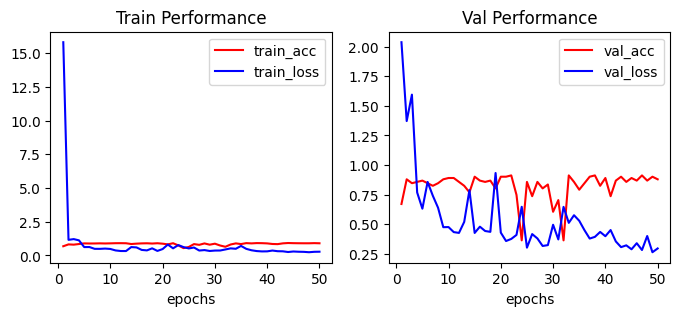

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,3))
plt.subplot(1,2,1)
plt.title('Train Performance')
plt.xlabel('epochs')
plt.plot(np.arange(1,51),model.history.history['acc'],color='r',label='train_acc')
plt.plot(np.arange(1,51),model.history.history['loss'],color='b',label='train_loss')

plt.legend(loc=0)

plt.subplot(1,2,2)
plt.title('Val Performance')
plt.xlabel('epochs')
plt.plot(np.arange(1,51),model.history.history['val_acc'],color='r',label='val_acc')
plt.plot(np.arange(1,51),model.history.history['val_loss'],color='b',label='val_loss')


plt.legend(loc=0)

plt.show()